In [1]:
import os
import sys
from glob import glob
import warnings

sys.path.insert(1, os.path.abspath(".."))
from pairs_python.core import pairs_quadtree as pqt

import numpy
import pandas
from datetime import datetime, timedelta
import pytz
import geopandas
import shapely
from shapely import wkb
import pyproj
import contextily
#import sqlite3
#import pysqlite3 as sqlite3

import spatialite
"""
# sudo apt-get install libsqlite3-mod-spatialite
# pip install spatialite
import spatialite
with spatialite.connect('sl_temp.db') as db:
    print(db.execute('SELECT spatialite_version()').fetchone()[0])
"""

from functools import partial
import json

import vectorstore
"""
from importlib import reload 
reload(vectorstore)
"""

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import StrMethodFormatter, NullFormatter

In [2]:
dataset = 'ne_10m_admin_0_countries_ORIGINAL_LEVEL1'
countries = vectorstore.Vectorstore(dataset=dataset)
countries.read_vectorstore_settings()

dataset = 'ne_10m_admin_1_states_provinces_ORIGINAL_LEVEL1'
states = vectorstore.Vectorstore(dataset=dataset)
states.read_vectorstore_settings()

dataset = 'ne_10m_admin_2_counties_ORIGINAL_LEVEL1'
counties = vectorstore.Vectorstore(dataset=dataset)
counties.read_vectorstore_settings()

In [3]:
%%time
#countries.query_vectorstore()
#gdf_countries = countries.gdf_query
states.query_vectorstore()
gdf_states = states.gdf_query
#counties.query_vectorstore()
#gdf_counties = counties.gdf_query

CPU times: user 5.07 s, sys: 317 ms, total: 5.39 s
Wall time: 5.2 s


In [4]:
gdf_states[(gdf_states['name']=='California')]

,ogc_fid,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,...,fclass_nl,fclass_se,fclass_bd,fclass_ua,fclass_tlc,timestamp,spatial_key,overview_level,overview_key,geometry
1076,1258,Admin-1 states provinces,2,USA-3521,3521,US-CA,http://en.wikipedia.org/wiki/California,US,8,California,...,None,None,None,None,None,2022-01-01 00:00:00+00:00,0,1,level1_0,"MULTIPOLYGON (((-114.76454 32.70984, -114.8380..."


In [5]:
dataset = 'kaggle_wildfire'
vs = vectorstore.Vectorstore(dataset=dataset)
vs.read_vectorstore_settings()
#vars(vs)

In [6]:
%%time
#query_polygon = shapely.geometry.box(-120, 30, -90, 50)
query_polygon = gdf_states.loc[(gdf_states['name']=='Colorado'), 'geometry'].values[0] #shapely.geometry.box(-180, -90, 180, 90)
query_dt_start = None #datetime(2000, 1, 1).replace(tzinfo=pytz.utc)
query_dt_end = None #datetime(2022, 6, 30).replace(tzinfo=pytz.utc)
query_intersection_policy = None #None 'cut' 'original'

vs.query_vectorstore(
    query_polygon=query_polygon, query_dt_start=query_dt_start, query_dt_end=query_dt_end, 
    query_intersection_policy=query_intersection_policy, verbose=False
)
gdf_query = vs.gdf_query
gdf_query.tail(2)

CPU times: user 5.67 s, sys: 604 ms, total: 6.27 s
Wall time: 5.7 s


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIPS_CODE,FIPS_NAME,Shape,timestamp,spatial_key,overview_level,overview_key,partition_level4,partition_level6,geometry
34157,1789607,300200866,FS-6362128,FED,FS-FIRESTAT,FS,USCOPSF,Pike and San Isabel National Forest,0212,Pike and San Isabel National Forest,...,059,Jefferson,b'\x00\x01\xad\x10\x00\x00\xb8\x1dm^MPZ\xc0xb\...,2015-11-07 00:00:00+00:00,3751,8,level8_3751,14,234,"POLYGON ((-105.25452 39.23693, -105.25452 39.2..."
34158,1789608,300200867,FS-6362133,FED,FS-FIRESTAT,FS,USCOPSF,Pike and San Isabel National Forest,0212,Pike and San Isabel National Forest,...,059,Jefferson,b'\x00\x01\xad\x10\x00\x00p<\xf2I\x9fPZ\xc0\xf...,2015-11-07 00:00:00+00:00,3751,8,level8_3751,14,234,"POLYGON ((-105.25959 39.23277, -105.25959 39.2..."


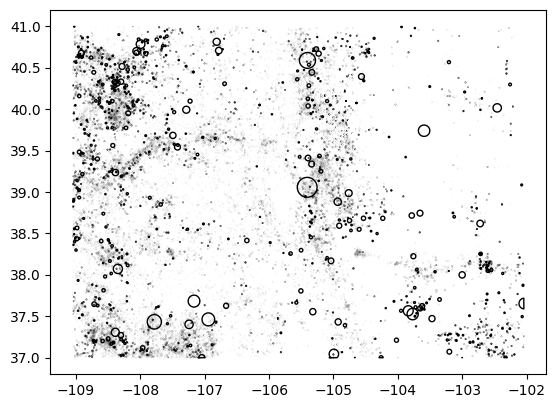

In [24]:
ax = gdf_query.plot(color='None')

In [54]:
%%time
def _create_bbKey_column(gdf, level): 
    # Bottom left keys
    gdf[f'bbKey_level{level}'] = pqt.getKey_vect(gdf['bb_miny'], gdf['bb_minx'], level)
    # Top_right_keys
    top_right_keys = pqt.getKey_vect(gdf['bb_maxy'], gdf['bb_maxx'], level)
    # Overwrite in cases where the would be more than one cell
    gdf.loc[gdf[f'bbKey_level{level}']!=top_right_keys, f'bbKey_level{level}'] = numpy.nan
    return gdf

def _create_bbKey_columns(gdf, bb_key_levels): 
    # Getting the bounds seems to require most of the time
    gdf[['bb_minx', 'bb_miny', 'bb_maxx', 'bb_maxy']] = gdf['geometry'].apply(lambda x: x.bounds).to_list()
    # Efficient way of getting the bounding-box keys 
    for level in bb_key_levels:
        gdf = _create_bbKey_column(gdf_query, level)
    # Decide here if we want to keep the geometry bounds
    gdf = gdf.drop(columns=['bb_minx', 'bb_miny', 'bb_maxx', 'bb_maxy'])
    return gdf

bb_key_levels = [10, 14, 18, 22]
gdf = _create_bbKey_columns(gdf_query, bb_key_levels)
gdf.tail(2)

CPU times: user 2.87 s, sys: 7.93 ms, total: 2.87 s
Wall time: 2.87 s


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,spatial_key,overview_level,overview_key,partition_level4,partition_level6,geometry,bbKey_level10,bbKey_level14,bbKey_level18,bbKey_level22
34157,1789607,300200866,FS-6362128,FED,FS-FIRESTAT,FS,USCOPSF,Pike and San Isabel National Forest,0212,Pike and San Isabel National Forest,...,3751,8,level8_3751,14,234,"POLYGON ((-105.25452 39.23693, -105.25452 39.2...",60028.0,NaN,NaN,NaN
34158,1789608,300200867,FS-6362133,FED,FS-FIRESTAT,FS,USCOPSF,Pike and San Isabel National Forest,0212,Pike and San Isabel National Forest,...,3751,8,level8_3751,14,234,"POLYGON ((-105.25959 39.23277, -105.25959 39.2...",60028.0,15367274.0,3.934022e+09,NaN


In [22]:
gdf_query.tail(2)

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,partition_level6,geometry,bb_minx,bb_miny,bb_maxx,bb_maxy,bbKey_level10,bbKey_level14,bbKey_level18,bbKey_level22
34157,1789607,300200866,FS-6362128,FED,FS-FIRESTAT,FS,USCOPSF,Pike and San Isabel National Forest,0212,Pike and San Isabel National Forest,...,234,"POLYGON ((-105.25452 39.23693, -105.25452 39.2...",-105.254930,39.236783,-105.254515,39.237106,60028.0,NaN,NaN,NaN
34158,1789608,300200867,FS-6362133,FED,FS-FIRESTAT,FS,USCOPSF,Pike and San Isabel National Forest,0212,Pike and San Isabel National Forest,...,234,"POLYGON ((-105.25959 39.23277, -105.25959 39.2...",-105.259854,39.232676,-105.259591,39.232880,60028.0,15367274.0,3.934022e+09,NaN


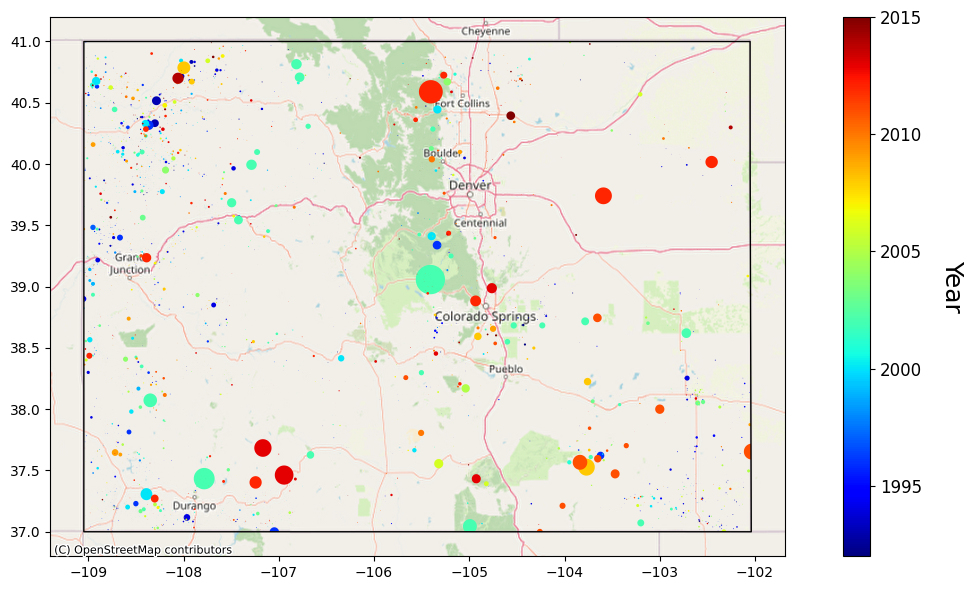

In [41]:
ax = gdf_query.plot(column='FIRE_YEAR', cmap='jet', figsize=(12,6), legend=True)
aspect = ax._aspect # Remember the aspect from here.
gdf_query_polygon = vs.polygons2geodataframe([query_polygon], geom_col='geometry')
gdf_query_polygon.plot(ax=ax, color='none')
contextily.add_basemap(ax, crs=gdf_query.crs.to_string(), zoom=7, source=contextily.providers.OpenStreetMap.Mapnik, interpolation='sinc')
ax.set_aspect(aspect)
cb_ax = ax.figure.axes[1]
cb_ax.tick_params(labelsize=12)
cb_ax.set_ylabel('Year', rotation=-90, labelpad=30, size=18)
plt.tight_layout()
plt.show()

In [9]:
# Query the parquet vector store (single file)
query_latitude = 38.03389  #38
query_longitude = -121.97889 #-122 #-120
query_dt = datetime(2000, 3, 21, tzinfo=pytz.utc)
spatial_filter = False
temporal_filter = False

vs = vectorstore.Vectorstore(dataset=dataset)

vs.query_single_parquet(
    query_latitude=query_latitude, 
    query_longitude=query_longitude, 
    query_dt=query_dt, 
    spatial_filter=spatial_filter, 
    temporal_filter=temporal_filter,
)

gdf_query = vs.gdf_query
gdf_query.tail()

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIPS_CODE,FIPS_NAME,Shape,geometry,timestamp,spatial_key,overview_level,overview_key,partition_level4,partition_level6
22614,1871756,300308098,SFO-2015CACDFBTU017874,NONFED,ST-NASF,ST/C&L,USCABTU,Butte Unit,CABTU,Butte Unit,...,007,Butte,b'\x00\x01\xad\x10\x00\x00\xec]\x83\xbe\xf4a^\...,"POLYGON ((-121.53052 39.47941, -121.53052 39.4...",2015-12-05 00:00:00+00:00,3047,8,level8_3047,11,190
22615,1871738,300308080,SFO-2015CACDFLNU012063,NONFED,ST-NASF,ST/C&L,USCALNU,Sonoma-Lake Napa Unit,CALNU,Sonoma-Lake Napa Unit,...,097,Sonoma,b'\x00\x01\xad\x10\x00\x00$/2\x01\xbf\xa2^\xc0...,"POLYGON ((-122.54287 38.24517, -122.54287 38.2...",2015-12-15 00:00:00+00:00,3047,8,level8_3047,11,190
22616,1871736,300308078,SFO-2015CACDFNEU029463,NONFED,ST-NASF,ST/C&L,USCANEU,Nevada-Yuba-Placer Unit,CANEU,Nevada-Yuba-Placer Unit,...,061,Placer,b'\x00\x01\xad\x10\x00\x00P\x84\xd4\xed\xecY^\...,"POLYGON ((-121.40504 38.89720, -121.40504 38.8...",2015-12-17 00:00:00+00:00,3047,8,level8_3047,11,190
22617,1872138,300308500,SFO-2015CACDFNEU029459,NONFED,ST-NASF,ST/C&L,USCANEU,Nevada-Yuba-Placer Unit,CANEU,Nevada-Yuba-Placer Unit,...,061,Placer,b'\x00\x01\xad\x10\x00\x00\x14e6\xc8$X^\xc0P\x...,"POLYGON ((-121.37720 38.94095, -121.37720 38.9...",2015-12-17 00:00:00+00:00,3047,8,level8_3047,11,190
22618,1872103,300308464,SFO-2015CACDFLNU012339,NONFED,ST-NASF,ST/C&L,USCALNU,Sonoma-Lake Napa Unit,CALNU,Sonoma-Lake Napa Unit,...,097,Sonoma,b'\x00\x01\xad\x10\x00\x00\x04\x9b:\x8f\x8a\xb...,"POLYGON ((-122.99279 38.49871, -122.99279 38.4...",2015-12-25 00:00:00+00:00,3047,8,level8_3047,11,190


In [10]:
# Discover the vectorstore cells of the dataset
vs.metadata_from_parquet()
gdf_meta = vs.gdf_meta
gdf_meta.tail()

,spatial_key,overview_level,geometry,partition_level4,partition_level6,overview_key,filepath
333,9477,8,"POLYGON ((-70.94810 44.21773, -70.94810 46.314...",37,592,level8_9477,/data/vector/vectorstore/kaggle_wildfire/parti...
334,9488,8,"POLYGON ((-68.85094 44.21773, -68.85094 46.314...",37,593,level8_9488,/data/vector/vectorstore/kaggle_wildfire/parti...
335,9489,8,"POLYGON ((-66.75379 44.21773, -66.75379 46.314...",37,593,level8_9489,/data/vector/vectorstore/kaggle_wildfire/parti...
336,9490,8,"POLYGON ((-68.85094 46.31488, -68.85094 48.412...",37,593,level8_9490,/data/vector/vectorstore/kaggle_wildfire/parti...
337,9491,8,"POLYGON ((-66.75379 46.31488, -66.75379 48.412...",37,593,level8_9491,/data/vector/vectorstore/kaggle_wildfire/parti...


In [11]:
%%time
"""
numeric_layers = ['FIRE_SIZE', 'DISCOVERY_DOY']
timestamp_layers = ['timestamp']
categorical_layers = ['STATE', 'STAT_CAUSE_DESCR']
histogram_for_categorical_layers = True
percentiles = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]
vs.calc_overview_statistics(
    numeric_layers=numeric_layers,
    timestamp_layers=timestamp_layers,
    categorical_layers=categorical_layers,
    histogram_for_categorical_layers=histogram_for_categorical_layers,
    percentiles=percentiles,
)
"""

CPU times: user 13 µs, sys: 2 µs, total: 15 µs
Wall time: 26.5 µs


"\nnumeric_layers = ['FIRE_SIZE', 'DISCOVERY_DOY']\ntimestamp_layers = ['timestamp']\ncategorical_layers = ['STATE', 'STAT_CAUSE_DESCR']\nhistogram_for_categorical_layers = True\npercentiles = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]\nvs.calc_overview_statistics(\n    numeric_layers=numeric_layers,\n    timestamp_layers=timestamp_layers,\n    categorical_layers=categorical_layers,\n    histogram_for_categorical_layers=histogram_for_categorical_layers,\n    percentiles=percentiles,\n)\n"

In [12]:
layer = 'STAT_CAUSE_DESCR' #'labelrank' #'timestamp' #'STAT_CAUSE_DESCR'
vs.read_overview_statistics(layer)
#vs.read_overview_histogram(layer)

,overview_key,count,unique,top,freq
0,level8_2639,22,1,Missing/Undefined,22
1,level8_2659,915,3,Missing/Undefined,912
2,level8_2660,47,2,Missing/Undefined,46
3,level8_2661,2097,9,Missing/Undefined,1929
4,level8_2662,6806,7,Missing/Undefined,6798
...,...,...,...,...,...
333,level8_9477,419,13,Debris Burning,143
334,level8_9488,4443,12,Missing/Undefined,2081
335,level8_9489,4384,13,Missing/Undefined,1988
336,level8_9490,176,8,Missing/Undefined,93


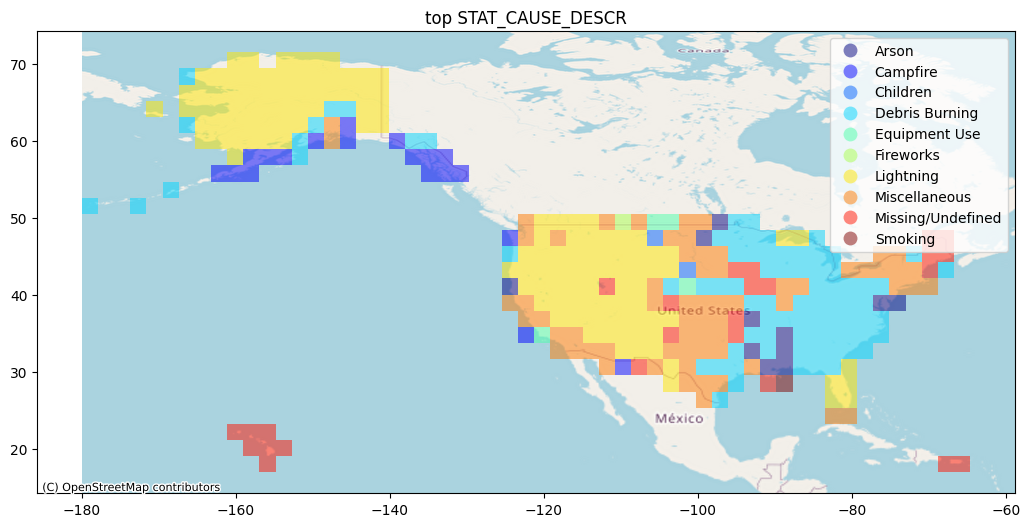

In [13]:
layer = 'STAT_CAUSE_DESCR'
statistics = 'top' #'Arson' #'count' #'95%'
df_cell_statistics = vs.read_overview_statistics(layer)
#year = 2010
df = pandas.merge(gdf_meta, df_cell_statistics, on=vs.overview_key_col)
#ax = df[df['year']==year].plot(column=statistics, cmap='jet', alpha=0.5, legend=True, figsize=(20,6))
ax = df.plot(column=statistics, cmap='jet', alpha=0.5, legend=True, figsize=(20,6))
contextily.add_basemap(ax, crs=gdf_query.crs.to_string(), zoom=3, source=contextily.providers.OpenStreetMap.Mapnik, interpolation='sinc')
#plt.title(statistics + ' ' + layer + ' ' + str(year))
plt.title(statistics + ' ' + layer)
plt.show()

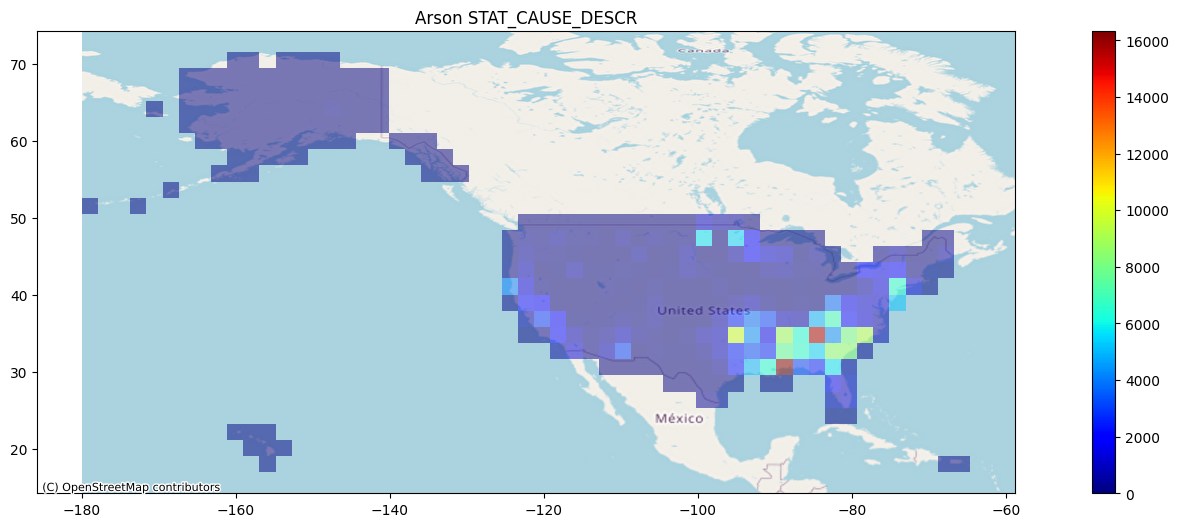

In [14]:
layer = 'STAT_CAUSE_DESCR'
statistics = 'Arson' #'top' #'Arson' #'count' #'95%'
df_cell_statistics = vs.read_overview_histogram(layer)
#year = 2010
df = pandas.merge(gdf_meta, df_cell_statistics, on=vs.overview_key_col)
#ax = df[df['year']==year].plot(column=statistics, cmap='jet', alpha=0.5, legend=True, figsize=(20,6))
ax = df.plot(column=statistics, cmap='jet', alpha=0.5, legend=True, figsize=(20,6))
contextily.add_basemap(ax, crs=gdf_query.crs.to_string(), zoom=3, source=contextily.providers.OpenStreetMap.Mapnik, interpolation='sinc')
#plt.title(statistics + ' ' + layer + ' ' + str(year))
plt.title(statistics + ' ' + layer)
plt.show()

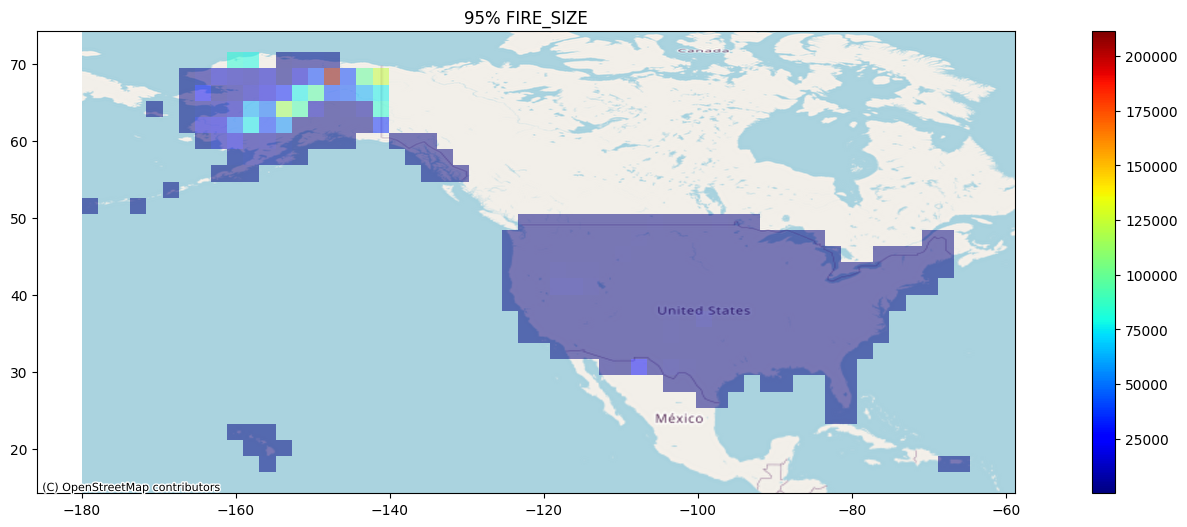

In [15]:
layer = 'FIRE_SIZE'
statistics = '95%'
df_cell_statistics = vs.read_overview_statistics(layer)
#year = 2015
df = pandas.merge(gdf_meta, df_cell_statistics, on=vs.overview_key_col)
#ax = df[df['year']==year].plot(column=statistics, cmap='jet', alpha=0.5, legend=True, figsize=(20,6))
ax = df.plot(column=statistics, cmap='jet', alpha=0.5, legend=True, figsize=(20,6))
contextily.add_basemap(ax, crs=gdf_query.crs.to_string(), zoom=3, source=contextily.providers.OpenStreetMap.Mapnik, interpolation='sinc')
#plt.title(statistics + ' ' + layer + ' ' + str(year))
plt.title(statistics + ' ' + layer)
plt.show()

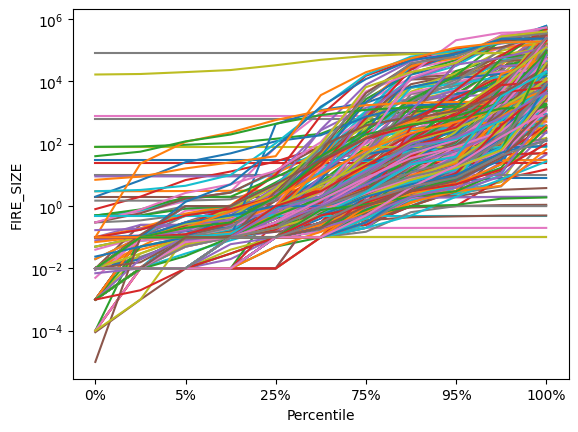

In [16]:
layer = 'FIRE_SIZE' #'DISCOVERY_DOY'
statistics = '95%'
df_cell_statistics = vs.read_overview_statistics(layer)
#year = 2015
logy = True
df_cell_statistics[[c for c in df_cell_statistics.columns if '%' in c]].T.plot(logy=logy, legend=None)
plt.xlabel('Percentile')
plt.ylabel(layer)
plt.show()

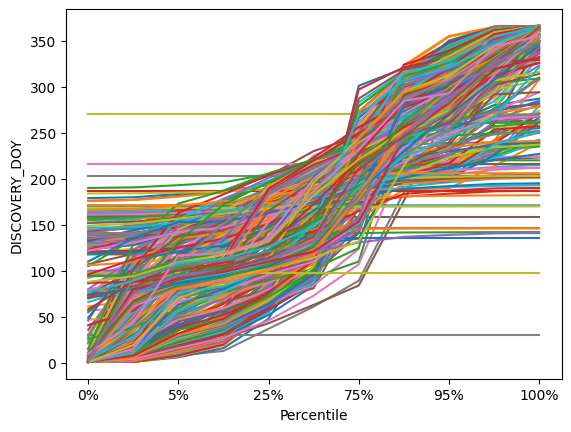

In [17]:
layer = 'DISCOVERY_DOY' #'FIRE_SIZE' #
statistics = '95%'
df_cell_statistics = vs.read_overview_statistics(layer)
year = 2015
logy = False
df_cell_statistics[[c for c in df_cell_statistics.columns if '%' in c]].T.plot(logy=logy, legend=None)
plt.xlabel('Percentile')
plt.ylabel(layer)
plt.show()